<a href="https://colab.research.google.com/github/Khaledblel/player-market-value-prediction/blob/main/notebooks/01_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 01. Exploratory Data Analysis (EDA)
**Project:** Predicting Football Player Market Values
**Author:** Khaled Blel (4 Data Science 2)

In this notebook, we load our merged and cleaned dataset (`processed_valuations.csv`) to conduct our exploratory data analysis. We will investigate:
1. The distribution of our target variable (`market_value_in_eur`).
2. The correlation between player age, performance, and market value.
3. Outliers and categorical distributions (League tiers, player positions).

## 1. Import Libraries & Load Master Data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid") # Sets a clean theme for our charts
pd.set_option('display.float_format', lambda x: '%.3f' % x)

# Load the master CSV we created in the previous notebook
df = pd.read_csv("processed_valuations.csv")

print(f"Data loaded successfully! Shape: {df.shape}")
display(df.head(3))

Data loaded successfully! Shape: (524838, 24)


,player_id,date,market_value_in_eur,current_club_name,current_club_id,position,sub_position,foot,height_in_cm,country_of_citizenship,...,career_minutes_played,career_goals,career_assists,career_yellow_cards,career_red_cards,recent_365d_minutes_played,recent_365d_goals,recent_365d_assists,recent_365d_yellow_cards,recent_365d_red_cards
0,3132,2003-12-09,400000,Dynamo Kyiv,126.000,Midfield,Attacking Midfield,left,168.000,Romania,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
1,6893,2003-12-15,900000,Galatasaray,984.000,Defender,Centre-Back,right,188.000,Romania,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
2,14041,2004-10-04,50000,Crystal Palace,1032.000,Midfield,Defensive Midfield,both,188.000,Antigua and Barbuda,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000


---
## 2. Data Quality Check
During our data preparation phase, we attached historical performance stats using a backward `merge_asof`. If a player had no recorded matches prior to their valuation date, this resulted in missing values (`NaN`), which we explicitly filled with `0`s.

Let's visualize when these "Zero-Stat" rows occur. We must remove them from our dataset, as keeping them will teach our model a false pattern (e.g., falsely learning that players with absolutely no match history can be worth millions of euros).

Total rows with absolutely 0 performance stats: 208284 out of 524838 (39.69%)


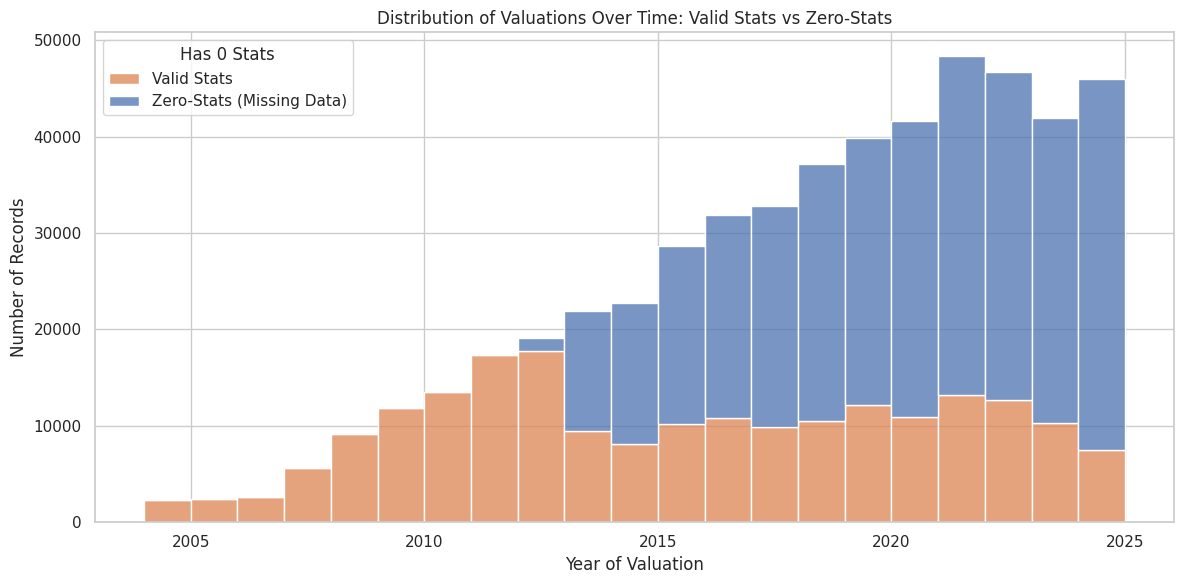


Dataset size after removing zero-stat anomalies: (316554, 24)


In [ ]:
# Define the columns that represent our performance metrics
perf_cols =[
    'career_minutes_played', 'career_goals', 'career_assists', 'career_yellow_cards', 'career_red_cards',
    'recent_365d_minutes_played', 'recent_365d_goals', 'recent_365d_assists', 'recent_365d_yellow_cards', 'recent_365d_red_cards'
]

# 1. Identify rows where ALL performance columns are exactly 0
df['is_zero_stat'] = (df[perf_cols] == 0).all(axis=1)

zero_stats_count = df['is_zero_stat'].sum()
total_count = len(df)
print(f"Total rows with absolutely 0 performance stats: {zero_stats_count} out of {total_count} ({(zero_stats_count/total_count)*100:.2f}%)")

# 2. Convert date to datetime if it isn't already
df['date'] = pd.to_datetime(df['date'])
df['valuation_year'] = df['date'].dt.year

# Plot the distribution of zero-stat rows over time
plt.figure(figsize=(12, 6))
sns.histplot(data=df, x='valuation_year', hue='is_zero_stat', multiple='stack', bins=range(2004, 2026))
plt.title('Distribution of Valuations Over Time: Valid Stats vs Zero-Stats')
plt.xlabel('Year of Valuation')
plt.ylabel('Number of Records')
plt.legend(title='Has 0 Stats', labels=['Valid Stats', 'Zero-Stats (Missing Data)'])
plt.tight_layout()
plt.show()

# 3. Clean the dataset: Remove these misleading rows
df_clean = df[df['is_zero_stat'] == False].copy()
df_clean.drop(columns=['is_zero_stat', 'valuation_year'], inplace=True)

print(f"\nDataset size after removing zero-stat anomalies: {df_clean.shape}")

---
## 3. Feature Selection: Investigating Low Variance Features (`sub_type`)
During manual inspection, we noticed that the `sub_type` column (which indicates the league tier) almost exclusively contains "first_tier" or "Unknown".

In Machine Learning, a feature with **zero or low variance** provides no predictive power because it doesn't help the model differentiate between instances. Let's visualize the distribution of `sub_type` and compare it to `is_major_national_league` to see which one we should keep for our modeling phase.

Value Counts for 'sub_type':
sub_type
first_tier   93.768
Unknown       6.232
Name: proportion, dtype: float64

Cross-Tabulation (sub_type vs is_major_national_league):


is_major_national_league,False,True
sub_type,,
Unknown,19728,0
first_tier,176027,120799


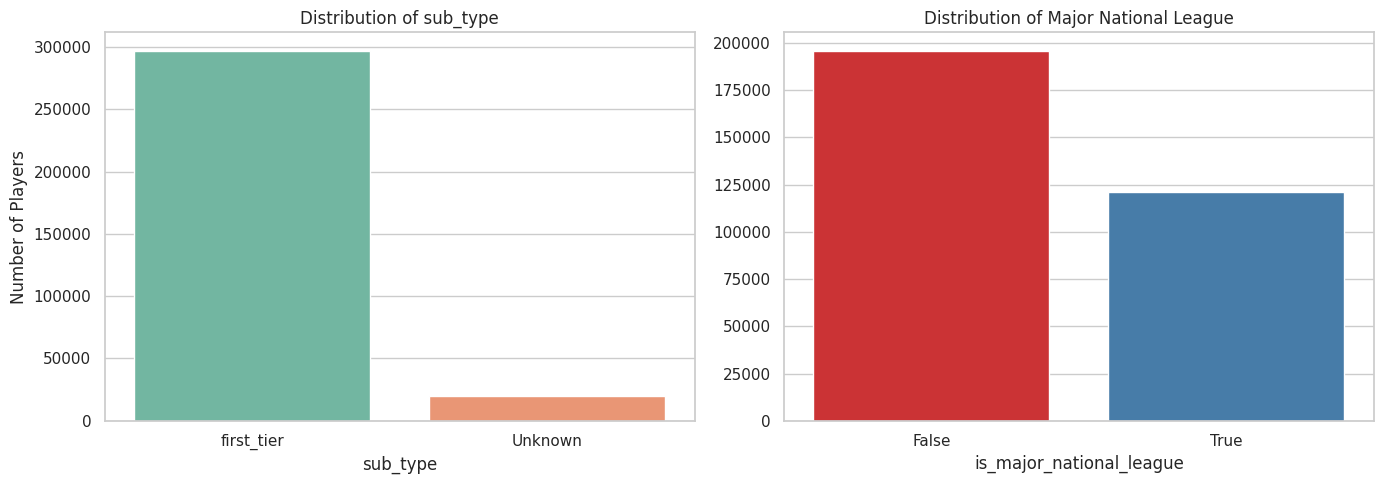


Conclusion: 'sub_type' lacks variance. 'is_major_national_league' is a much better differentiator.
Column 'sub_type' dropped. Remaining columns: 23


In [ ]:
# 1. Print the exact counts of the sub_type column
print("Value Counts for 'sub_type':")
print(df_clean['sub_type'].value_counts(normalize=True) * 100)

# 2. Let's cross-tabulate sub_type with is_major_national_league
print("\nCross-Tabulation (sub_type vs is_major_national_league):")
display(pd.crosstab(df_clean['sub_type'], df_clean['is_major_national_league']))

# 3. Visualizing the distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: sub_type
sns.countplot(data=df_clean, x='sub_type', ax=axes[0], palette='Set2')
axes[0].set_title('Distribution of sub_type')
axes[0].set_ylabel('Number of Players')

# Plot 2: is_major_national_league
sns.countplot(data=df_clean, x='is_major_national_league', ax=axes[1], palette='Set1')
axes[1].set_title('Distribution of Major National League')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

# 4. Drop the redundant column based on our findings
print("\nConclusion: 'sub_type' lacks variance. 'is_major_national_league' is a much better differentiator.")
df_clean.drop(columns=['sub_type'], inplace=True)

print(f"Column 'sub_type' dropped. Remaining columns: {len(df_clean.columns)}")

---
## 4. Time-Series Analysis: Football Market Inflation
A critical domain-specific factor in football is market inflation. For example, €10M in 2014 does not represent the same caliber of player as €10M in 2026.

Let's visualize the average market value per year. If there is a clear upward trend, we must ensure our predictive model has access to the `valuation_year` feature so it can account for this economic inflation.

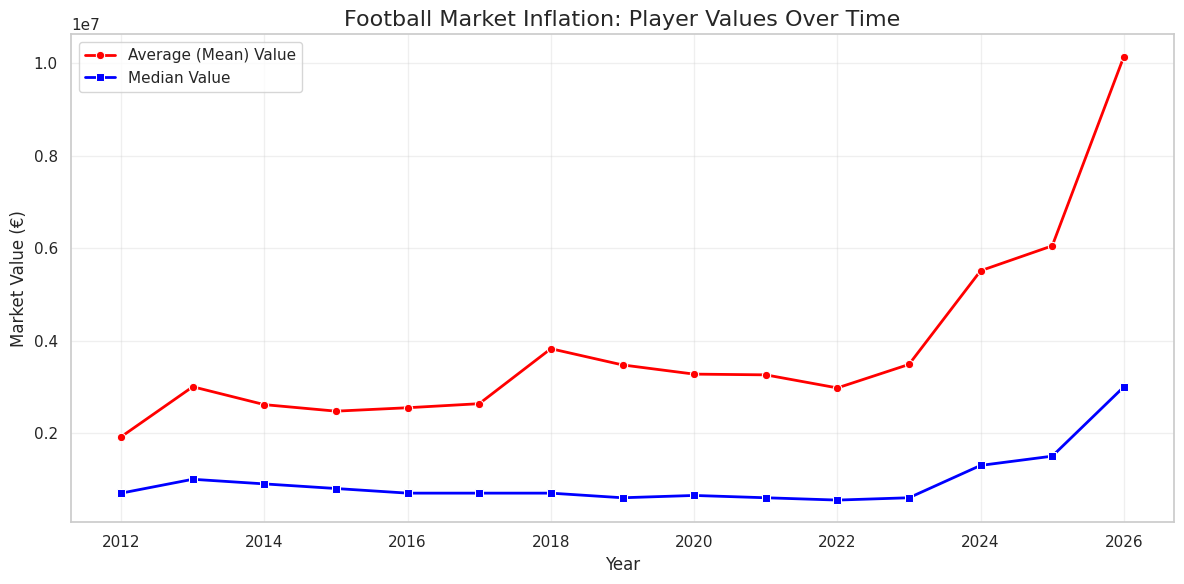

In [ ]:
# 1. Extract the year from the valuation date
df_clean['valuation_year'] = df_clean['date'].dt.year

# 2. Calculate the median and mean market value per year
yearly_stats = df_clean.groupby('valuation_year')['market_value_in_eur'].agg(['mean', 'median']).reset_index()

# 3. Plot the trend
plt.figure(figsize=(12, 6))

# Plotting the Mean
sns.lineplot(data=yearly_stats, x='valuation_year', y='mean', marker='o', label='Average (Mean) Value', color='red', linewidth=2)

# Plotting the Median
sns.lineplot(data=yearly_stats, x='valuation_year', y='median', marker='s', label='Median Value', color='blue', linewidth=2)

plt.title('Football Market Inflation: Player Values Over Time', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Market Value (€)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 5. Handling High Cardinality Categorical Variables
We have several categorical columns with many unique values (Clubs and Nationalities).
*   We will drop `current_club_name` to save memory and keep `current_club_id`. In our modeling phase, we will apply **Target Encoding** to the Club ID to convert it into a meaningful numerical feature without expanding our dataset's dimensions.
*   We will keep both `country_of_citizenship` (Player Nationality) and `country_name` (League Location), as both represent distinct economic factors in a player's valuation.

In [ ]:
# 1. Drop the club name string column
if 'current_club_name' in df_clean.columns:
    df_clean.drop(columns=['current_club_name'], inplace=True)

# 2. Check the number of unique values of our categorical columns
cat_cols =['current_club_id', 'country_of_citizenship', 'country_name', 'position', 'sub_position']

print("Number of Unique Values per Categorical Feature:")
for col in cat_cols:
    if col in df_clean.columns:
        print(f"- {col}: {df_clean[col].nunique()} unique values")

print(f"\nFinal columns ready for EDA: {list(df_clean.columns)}")

Number of Unique Values per Categorical Feature:
- current_club_id: 2081 unique values
- country_of_citizenship: 178 unique values
- country_name: 15 unique values
- position: 5 unique values
- sub_position: 14 unique values

Final columns ready for EDA: ['player_id', 'date', 'market_value_in_eur', 'current_club_id', 'position', 'sub_position', 'foot', 'height_in_cm', 'country_of_citizenship', 'age_at_valuation', 'country_name', 'is_major_national_league', 'career_minutes_played', 'career_goals', 'career_assists', 'career_yellow_cards', 'career_red_cards', 'recent_365d_minutes_played', 'recent_365d_goals', 'recent_365d_assists', 'recent_365d_yellow_cards', 'recent_365d_red_cards', 'valuation_year']


---
## 6. Target Variable Analysis: The Right Skew & Log Transformation
Market values in football are exponentially distributed. A vast majority of players hold lower values, while a tiny elite holds astronomical values (> €100M). This creates a heavy right skew.

To prevent our regression models (especially Ridge/Lasso) from being overly penalized by these massive outliers, we apply a log transformation (`np.log1p`).

Skewness of original market value: 6.74
Skewness of log market value: 0.45


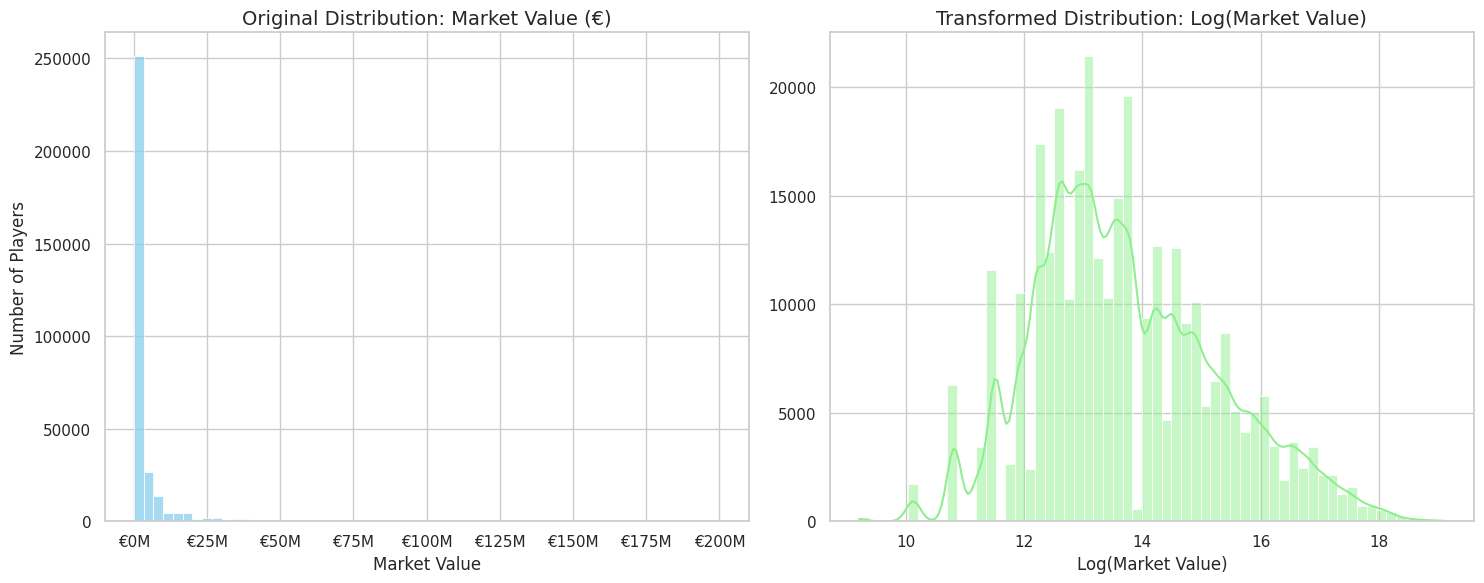

In [ ]:
if 'log_market_value' not in df_clean.columns:
    df_clean['log_market_value'] = np.log1p(df_clean['market_value_in_eur'])

# Set up the matplotlib figure
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Standard Market Value
sns.histplot(df_clean['market_value_in_eur'], bins=60, kde=False, ax=axes[0], color='skyblue')
axes[0].set_title('Original Distribution: Market Value (€)', fontsize=14)
axes[0].set_xlabel('Market Value', fontsize=12)
axes[0].set_ylabel('Number of Players', fontsize=12)

# Format the x-axis to show millions clearly
def format_millions(x, pos):
    return f'€{x*1e-6:.0f}M'
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(format_millions))

# Plot 2: Log-Transformed Market Value
sns.histplot(df_clean['log_market_value'], bins=60, kde=True, ax=axes[1], color='lightgreen')
axes[1].set_title('Transformed Distribution: Log(Market Value)', fontsize=14)
axes[1].set_xlabel('Log(Market Value)', fontsize=12)
axes[1].set_ylabel('')

# Add some statistics to the console
print("Skewness of original market value: {:.2f}".format(df_clean['market_value_in_eur'].skew()))
print("Skewness of log market value: {:.2f}".format(df_clean['log_market_value'].skew()))

plt.tight_layout()
plt.show()

---
## 7. Correlation Analysis & The "Aging Curve"
In this section, we measure the linear relationships between our numerical features and `log_market_value`.
*   **Heatmap:** We expect performance metrics (minutes played, goals) to have a strong positive correlation with value. We might also spot *multicollinearity* (e.g., if `recent_365d_goals` and `recent_365d_assists` are highly correlated with each other).
*   **The Aging Curve:** Age does not have a strictly linear relationship with market value. A player's value usually rises until their mid-to-late 20s and then declines. We will fit a polynomial trendline to visualize this biological and economic reality.

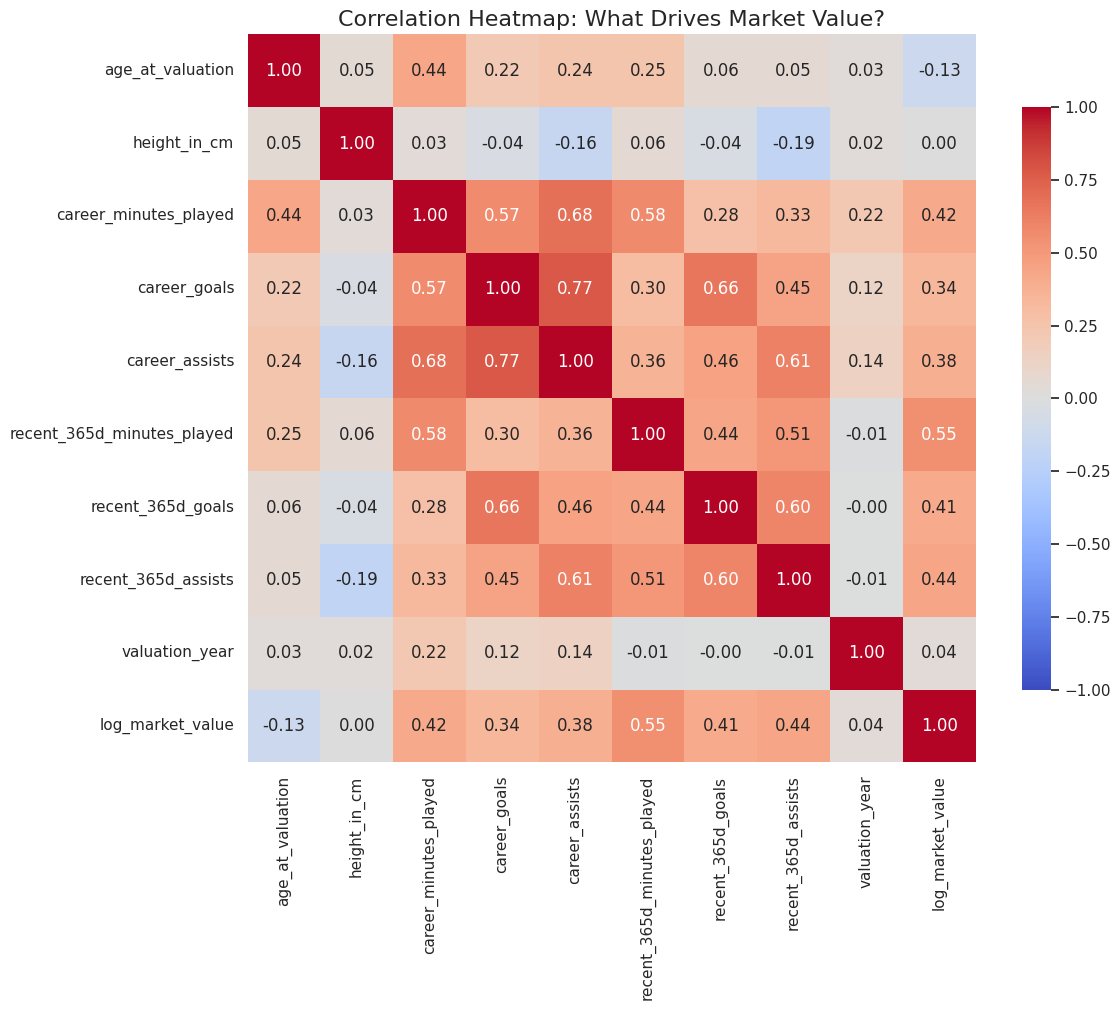

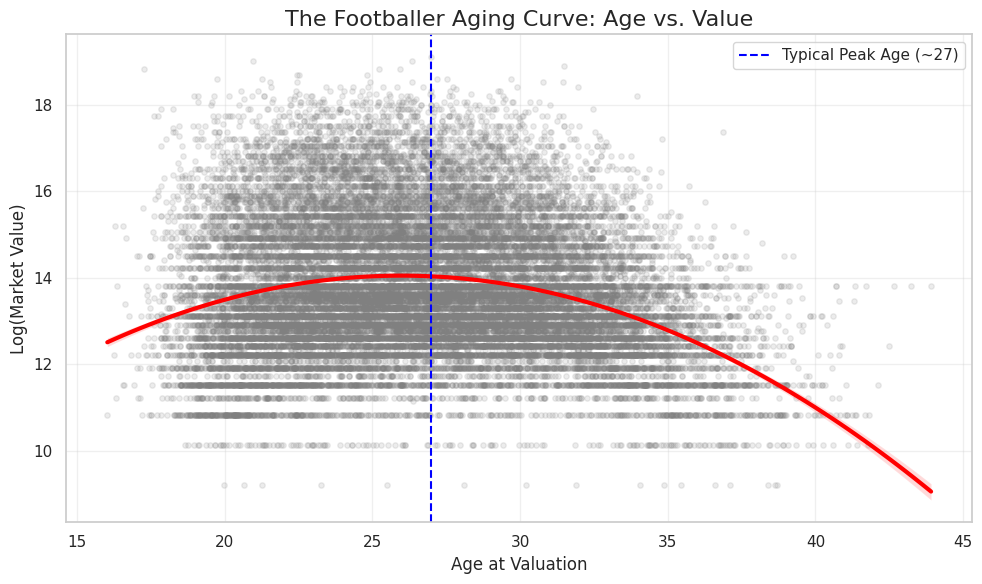

In [ ]:
# 1. Selecting the numerical columns we want to analyze
num_cols =[
    'age_at_valuation', 'height_in_cm',
    'career_minutes_played', 'career_goals', 'career_assists',
    'recent_365d_minutes_played', 'recent_365d_goals', 'recent_365d_assists',
    'valuation_year', 'log_market_value'
]

# Ensure we only use columns that actually exist in our cleaned dataframe
existing_num_cols =[c for c in num_cols if c in df_clean.columns]
corr_matrix = df_clean[existing_num_cols].corr()

# 2. Plot the Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    vmin=-1, vmax=1,
    square=True,
    cbar_kws={"shrink": .8}
)
plt.title('Correlation Heatmap: What Drives Market Value?', fontsize=16)
plt.tight_layout()
plt.show()

# 3. Plot the "Aging Curve"
plt.figure(figsize=(10, 6))

sample_df = df_clean.sample(n=min(30000, len(df_clean)), random_state=42)

sns.regplot(
    data=sample_df,
    x='age_at_valuation',
    y='log_market_value',
    scatter_kws={'alpha': 0.15, 'color': 'gray', 's': 15},
    line_kws={'color': 'red', 'linewidth': 3},
    order=2
)

plt.title('The Footballer Aging Curve: Age vs. Value', fontsize=16)
plt.xlabel('Age at Valuation', fontsize=12)
plt.ylabel('Log(Market Value)', fontsize=12)
plt.axvline(x=27, color='blue', linestyle='--', label='Typical Peak Age (~27)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 8. Categorical Analysis: Player Position & League Prestige
In this final EDA step, we examine how categorical features influence a player's market value. We will use boxplots to visualize the distribution of `log_market_value` across:
1.  **Player Position:** Do attackers inherently command higher market values than goalkeepers or defenders?
2.  **League Prestige:** How massive is the financial gap between Major National Leagues and the rest of the leagues?

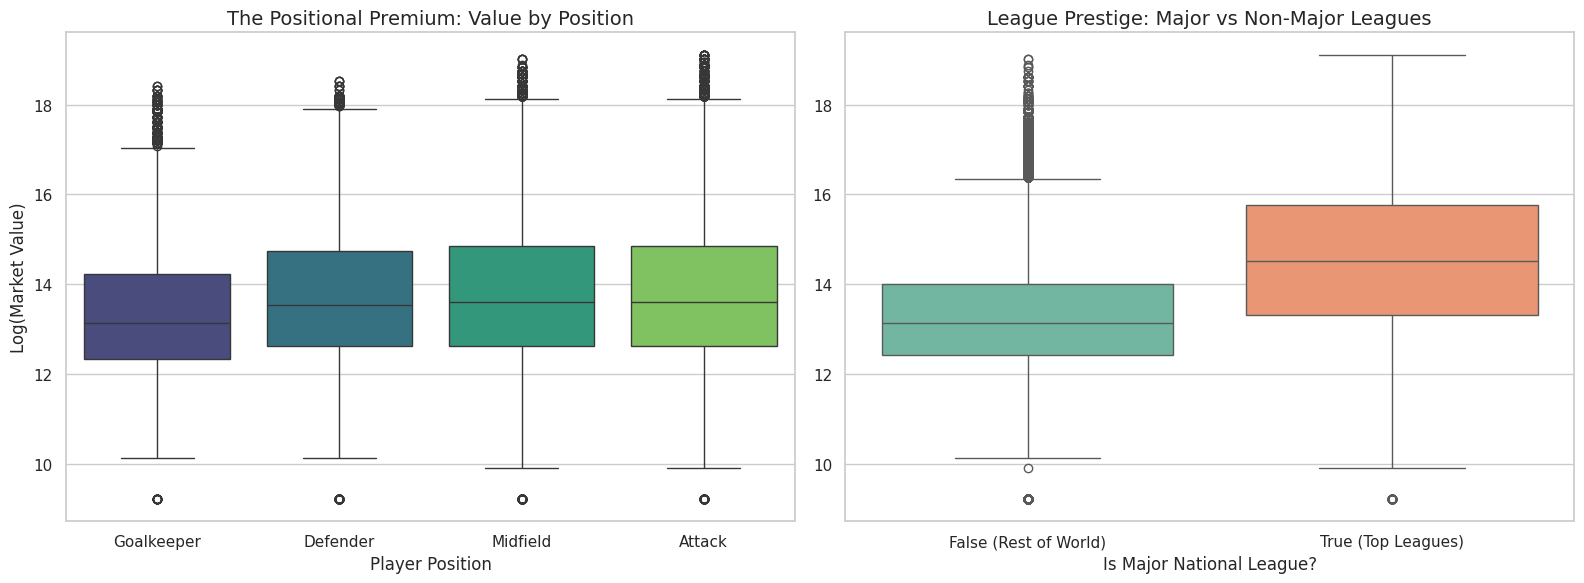

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Market Value by Position
position_order = ['Goalkeeper', 'Defender', 'Midfield', 'Attack']
plot_df = df_clean[df_clean['position'].isin(position_order)]

sns.boxplot(
    data=plot_df,
    x='position',
    y='log_market_value',
    order=position_order,
    palette='viridis',
    ax=axes[0]
)
axes[0].set_title('The Positional Premium: Value by Position', fontsize=14)
axes[0].set_xlabel('Player Position', fontsize=12)
axes[0].set_ylabel('Log(Market Value)', fontsize=12)

# Plot 2: Market Value by League Prestige
sns.boxplot(
    data=df_clean,
    x='is_major_national_league',
    y='log_market_value',
    palette='Set2',
    ax=axes[1]
)
axes[1].set_title('League Prestige: Major vs Non-Major Leagues', fontsize=14)
axes[1].set_xlabel('Is Major National League?', fontsize=12)
axes[1].set_ylabel('')
axes[1].set_xticklabels(['False (Rest of World)', 'True (Top Leagues)'])

plt.tight_layout()
plt.show()

---
## 8.5 Auditing Imputed Categorical Values
In the data preparation phase, missing categorical values (`NaN`) were temporarily filled with placeholders like 'Unknown' or 'Missing'.

Before moving to the modeling phase, we must analyze the volume of these placeholders.
*   If a category has a very small percentage of 'Unknowns' (e.g., < 1%), we can safely drop those rows.
*   If the percentage is larger, we must use a logical imputation strategy (e.g., inferring `foot` from `position`, or using the most frequent value).

Let's calculate the exact proportion of these placeholders in our dataset.

In [ ]:
# The columns we want to audit
audit_cols =['position', 'sub_position', 'foot', 'country_of_citizenship', 'country_name']

print("--- Audit of Placeholders ('Unknown' / 'Missing') ---")
total_rows = len(df_clean)

for col in audit_cols:
    if col in df_clean.columns:
        placeholder_count = df_clean[col].isin(['Unknown', 'Missing']).sum()
        percentage = (placeholder_count / total_rows) * 100
        print(f"{col}: {placeholder_count} rows ({percentage:.2f}%)")
# Printing Sample
if 'foot' in df_clean.columns:
    print("\nSample of rows with 'Unknown' foot:")
    display(df_clean[df_clean['foot'] == 'Unknown'][['player_id', 'position', 'foot', 'market_value_in_eur']].head(3))

--- Audit of Placeholders ('Unknown' / 'Missing') ---
position: 439 rows (0.14%)
sub_position: 439 rows (0.14%)
foot: 5703 rows (1.80%)
country_of_citizenship: 3005 rows (0.95%)
country_name: 19728 rows (6.23%)

Sample of rows with 'Unknown' foot:


,player_id,position,foot,market_value_in_eur
77961,44567,Attack,Unknown,1250000
78120,70554,Defender,Unknown,150000
78124,62680,Attack,Unknown,600000


---
## 8.6 Smart Data Imputation: Handling Categorical Placeholders
During our initial Data Preparation phase, we temporarily filled missing values (`NaN`) in several categorical columns with the placeholder `'Unknown'`. This was done intentionally to preserve row integrity during complex merges and early EDA.

Now that we are finalizing the dataset for modeling, we must resolve these placeholders. Instead of using generic imputation (like blindly filling with the mode), we apply domain-specific football logic:

1.  **`position` & `sub_position` (0.14%):** These placeholders exist in identical quantities. Because a player's position is a fundamental attribute that dictates their financial value, and 0.14% is a statistically negligible amount of data, we will safely **drop** the rows containing our `'Unknown'` placeholders here.
2.  **`foot` (1.80%):** Biologically, approximately 80% of professional footballers are right-footed. We will replace our `'Unknown'` placeholders in this column with `'right'`.
3.  **`country_name` (6.23%):** This represents the country of the league. We cannot use 'Other' for geographic data.
    *   *Step A:* We will group the data by `current_club_id` and propagate the known `country_name` of the club to the player.
    *   *Step B:* If the entire club's country is unknown, we will assume the player plays in their home country (`country_of_citizenship`).
4.  **`country_of_citizenship` (0.95%):** Football leagues typically have strict quotas on foreign players, meaning the majority of a squad is domestic. We will replace missing nationalities using the `country_name` (the country of the league they play in).

In [ ]:
import numpy as np

# Print starting shape
print(f"Starting shape: {df_clean.shape}")

# 1. Drop rows missing fundamental positional data (0.14%)
df_clean = df_clean[~df_clean['position'].isin(['Unknown', 'Missing'])]
df_clean = df_clean[~df_clean['sub_position'].isin(['Unknown', 'Missing'])]

# 2. Impute 'foot' with the biological majority ('right')
df_clean['foot'] = df_clean['foot'].replace(['Unknown', 'Missing'], 'right')

# --- Geographic Imputation ---
# Temporarily replace placeholders with np.nan so Pandas filling methods work natively
df_clean['country_name'] = df_clean['country_name'].replace(['Unknown', 'Missing'], np.nan)
df_clean['country_of_citizenship'] = df_clean['country_of_citizenship'].replace(['Unknown', 'Missing'], np.nan)

# 3A. Infer 'country_name' from 'current_club_id'
# Create a mapping of club_id to country_name by dropping NaNs and getting the first valid country per club
club_country_map = df_clean.dropna(subset=['country_name']).groupby('current_club_id')['country_name'].first()
df_clean['country_name'] = df_clean['country_name'].fillna(df_clean['current_club_id'].map(club_country_map))

# 3B. If club country is still missing, infer from the player's citizenship
df_clean['country_name'] = df_clean['country_name'].fillna(df_clean['country_of_citizenship'])

# 4. Infer missing 'country_of_citizenship' from the league's country
df_clean['country_of_citizenship'] = df_clean['country_of_citizenship'].fillna(df_clean['country_name'])

# 5. Drop any rows where geographic data was completely unrecoverable
df_clean = df_clean.dropna(subset=['country_name', 'country_of_citizenship'])

# --- Final Audit ---
# Check if any NaNs remain in our target columns
audit_cols =['position', 'sub_position', 'foot', 'country_name', 'country_of_citizenship']
print("\n--- Post-Imputation Audit ---")
for col in audit_cols:
    remaining_missing = df_clean[col].isna().sum() + df_clean[col].isin(['Unknown', 'Missing']).sum()
    print(f"{col}: {remaining_missing} missing/unknown rows remaining")

print(f"\nShape after categorical cleaning: {df_clean.shape}")

Starting shape: (316554, 24)

--- Post-Imputation Audit ---
position: 0 missing/unknown rows remaining
sub_position: 0 missing/unknown rows remaining
foot: 0 missing/unknown rows remaining
country_name: 0 missing/unknown rows remaining
country_of_citizenship: 0 missing/unknown rows remaining

Shape after categorical cleaning: (316103, 24)


---
## 8.7 Correcting Typographical Errors in Numerical Data
During our manual data inspection, we found 6 records where `height_in_cm` was listed as `18.000` or `19.000`.

Biologically, this is impossible for a professional athlete. This is a classic data entry typo where a trailing zero was omitted (e.g., 18 instead of 180 cm). To preserve the data's integrity rather than defaulting to the median height, we will multiply these specific anomalous values by 10.

In [ ]:
# 1. Show the anomalies before fixing
print("Anomalous heights before fix:")
print(df_clean['height_in_cm'].value_counts())
print(df_clean[df_clean['height_in_cm'] < 100]['height_in_cm'].value_counts())

# 2. Fix the typo by multiplying values under 50 by 10
df_clean.loc[df_clean['height_in_cm'] < 50, 'height_in_cm'] = df_clean['height_in_cm'] * 10

# 3. Verify the fix
print("\nLowest heights in the dataset after fix:")
print(df_clean['height_in_cm'].sort_values().head(5).values)

df_clean.to_csv("eda_final_dataset.csv", index=False)
print("\nAll missing values, placeholders, and typos have been resolved.")
print("The dataset has been saved as 'eda_final_dataset.csv'.")

Anomalous heights before fix:
height_in_cm
180.000    22378
183.000    22310
185.000    20076
178.000    17821
188.000    15960
184.000    15773
182.000    15560
186.000    15281
187.000    15182
175.000    14007
181.000    12693
190.000    12395
177.000    11607
179.000    11414
176.000    10513
189.000     9683
191.000     8777
174.000     8193
173.000     8150
172.000     6554
192.000     6178
193.000     5917
170.000     5830
171.000     3812
194.000     3536
195.000     2867
196.000     2532
169.000     2431
168.000     2257
197.000     1329
167.000     1117
198.000      909
165.000      731
166.000      577
201.000      324
199.000      300
164.000      281
163.000      204
200.000      179
203.000      114
202.000       95
162.000       66
206.000       34
161.000       33
159.000       32
204.000       26
207.000       19
205.000       19
160.000       14
158.000        7
18.000         3
19.000         3
Name: count, dtype: int64
height_in_cm
18.000    3
19.000    3
Name: coun

---
## 9. Descriptive Statistics & Summary of Findings
To formally conclude our Exploratory Data Analysis, we generate the descriptive statistics for both our numerical and categorical variables.

### Key Takeaways for Modeling:
1.  **Target Transformation:** The target variable `market_value_in_eur` is heavily right-skewed. We MUST use `log_market_value` as our target ($y$) during model training to ensure stable predictions.
2.  **Non-Linearity of Age:** The relationship between age and market value is curved (peaking around 27). Tree-based models (Random Forest, XGBoost) will handle this naturally, but if we use a Linear Model (Ridge/Lasso), we might need to add an `age_squared` feature.
3.  **Inflation:** The market has inflated significantly over time. `valuation_year` must be included as a feature.
4.  **Categorical Importance:** `is_major_national_league` and `position` are strong differentiators.
5.  **High Cardinality:** `current_club_id` and `country_of_citizenship` have too many unique values for One-Hot Encoding. We will use **Target Encoding** in the next notebook.

In [ ]:
print("--- Numerical Features Summary ---")
# .T transposes the table to make it easier to read when there are many columns
display(df_clean.describe().T)

print("\n--- Categorical & Boolean Features Summary ---")
# include=['O', 'bool'] selects Object (string) and Boolean columns
display(df_clean.describe(include=['O', 'bool']).T)

--- Numerical Features Summary ---


,count,mean,min,25%,50%,75%,max,std
player_id,316103.000,242500.290,10.000,73564.000,183720.000,342913.000,1510255.000,215662.190
date,316103,2020-02-08 20:13:06.867571712,2012-07-06 00:00:00,2017-06-08 00:00:00,2020-04-08 00:00:00,2022-11-09 00:00:00,2026-03-23 00:00:00,NaN
market_value_in_eur,316103.000,3475857.205,10000.000,300000.000,750000.000,2500000.000,200000000.000,8895724.112
current_club_id,316103.000,4698.515,1.000,369.000,1038.000,3060.000,133929.000,11241.348
height_in_cm,316103.000,182.247,158.000,178.000,183.000,187.000,207.000,6.623
age_at_valuation,316103.000,26.825,15.384,23.318,26.552,30.073,45.369,4.512
career_minutes_played,316103.000,4607.906,1.000,536.000,2352.000,6519.000,53556.000,5799.466
career_goals,316103.000,6.860,0.000,0.000,1.000,6.000,523.000,16.500
career_assists,316103.000,5.410,0.000,0.000,1.000,6.000,224.000,11.011
career_yellow_cards,316103.000,9.630,0.000,1.000,4.000,13.000,147.000,13.521



--- Categorical & Boolean Features Summary ---


,count,unique,top,freq
position,316103,4,Defender,102708
sub_position,316103,13,Centre-Back,56944
foot,316103,3,right,225138
country_of_citizenship,316103,177,Spain,23183
country_name,316103,145,Turkey,30263
is_major_national_league,316103,2,False,195462
